# Data analysis code for demographic reporting

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('../EUCA_quantitative_dataset/demography.csv')
df = df.replace({'Some college credit': 'Some college credit, no degree', 'high school':'High school', \
                 'professional':'Professional degree (e.g.: MD, JD)','Trade':'Trade/technical/vocational training'})
df = df.replace({'heard':'only hear of AI', 'never':'never hear of AI', \
                 r'^program .*': 'can code but not write AI code',
                 r'^use AI .*': 'use AI in work or life'}, regex=True)
edu = df['Edu'].value_counts()
ai = df['AI'].value_counts()
attitude=df['opinion_cleaned'].value_counts().to_dict()
# attitude = {'Positive':12,'Neutral':3, 'Negative': 3, 'Mixed':13}
# df.to_csv('demo_cleaned.csv')

In [3]:
df['opinion_cleaned'].value_counts().to_dict()

{'Mixed': 13, 'Positive': 12, 'Neutral': 3, 'Negative': 3}

## Reporting participants' age distribution

In [4]:
np.mean(df['Age']), np.std(df['Age']), np.min(df['Age']), np.max(df['Age'])

(38.1875, 15.752851924334209, 19, 73)

/Users/root202/Software/anaconda3/envs/posthoc-eval/lib/python3.8/site-packages/seaborn/distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/Users/root202/Software/anaconda3/envs/posthoc-eval/lib/python3.8/site-packages/seaborn/distributions.py:2055: FutureWarning: The `axis` variable is no longer used and will be removed. Instead, assign variables directly to `x` or `y`.
  warnings.warn(msg, FutureWarning)


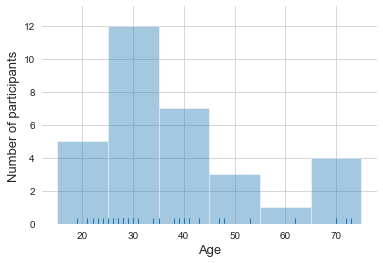

In [5]:
import matplotlib.ticker as ticker
fontsize = 13
sns.set_style("whitegrid")
# plt.figure(figsize=(10, 10))
g=sns.distplot(df['Age'], bins = 6, kde=False, rug=True, hist_kws={'range':(15,75)})
g.set_xlabel('Age', fontsize=fontsize)
g.set_ylabel('Number of participants',fontsize=fontsize)
sns.despine(left=True, bottom=True)
g.yaxis.set_major_locator(ticker.MultipleLocator(2))
# plt.savefig("age.pdf", transparent=True)


## Reporting participants' educational level distribution

In [6]:
edu = df['Edu'].value_counts()
edu

Bachelor                               15
Master                                  4
Some college credit, no degree          4
High school                             3
PhD                                     2
Trade/technical/vocational training     2
Professional degree (e.g.: MD, JD)      2
Name: Edu, dtype: int64

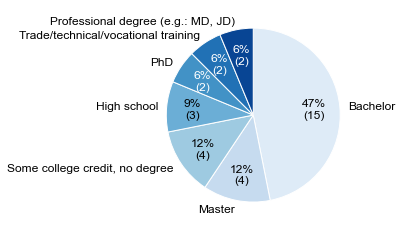

In [7]:
import matplotlib
matplotlib.rcParams.update({'font.size': 12})
blue_colors = ['#deebf7','#c6dbef','#9ecae1','#6baed6','#4292c6','#2171b5','#084594']
patches, texts, autotexts = plt.pie(edu, autopct=lambda p : '{:.0f}%\n({:,.0f})'.format(p,p * sum(edu)/100),\
                                    pctdistance=0.7, labels=edu.index,startangle=90,counterclock=False, colors=blue_colors)
for text in texts:
    text.set_color('black')
i = 0
for autext in autotexts:
    if i<4:
        autext.set_color('black')
    else:
        autext.set_color('white')
    i+=1
        
# plt.savefig("edu.pdf", transparent=True)


## Reporting participants' knowledge of AI distribution

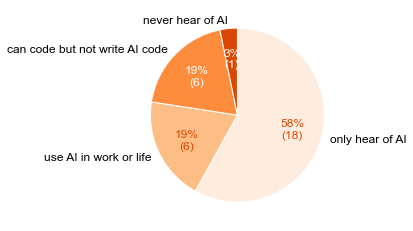

In [8]:
orange_colors = ['#feedde','#fdbe85','#fd8d3c','#d94701']
patches, texts, autotexts = plt.pie(ai, autopct=lambda p : '{:.0f}%\n({:,.0f})'.format(p,p * sum(ai)/100),\
                                    pctdistance=0.65, labels=ai.index,startangle=90,counterclock=False, colors=orange_colors)
for text in texts:
    text.set_color('black')
i = 0
for autext in autotexts:
    if i<2:
        autext.set_color(orange_colors[3])
    else:
        autext.set_color('white')
    i+=1
        
# plt.savefig("ai.pdf", transparent=True)


## Reporting participants' attitude of AI distribution

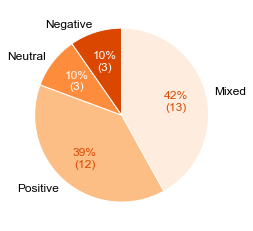

In [9]:
orange_colors = ['#feedde','#fdbe85','#fd8d3c','#d94701']
patches, texts, autotexts = plt.pie(attitude.values(), autopct=lambda p : '{:.0f}%\n({:,.0f})'.format(p,p * sum(attitude.values())/100),\
                                    pctdistance=0.65, labels=attitude.keys(),startangle=90,counterclock=False, colors=orange_colors)
for text in texts:
    text.set_color('black')
i = 0
for autext in autotexts:
    if i<2:
        autext.set_color(orange_colors[3])
    else:
        autext.set_color('white')
    i+=1
        
# plt.savefig("attitude.pdf", transparent=True)
